In [ ]:
import pandas as pd
import os

# Define the folder path established in Week 1
DATA_PATH = "../data/Crop_Recommendation.csv"


In [ ]:
if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print("✅ Dataset Found!")
    print(f"Columns: {df.columns.tolist()}")
    
    # Verify the specific headers required by your API
    expected_headers = ['Nitrogen', 'Phosphorus', 'Potassium', 'Temperature', 'Humidity', 'pH_Value', 'Rainfall']
    missing = [col for col in expected_headers if col not in df.columns]
    
    if not missing:
        print("✅ Workflow Review: Headers match app/model_utils.py")
    else:
        print(f"❌ Workflow Error: Missing columns {missing}")
else:
    print("⚠️ Dataset not found in /data folder. Please move Crop_Recommendation.csv there.")

In [ ]:
def check_synthetic_integrity(synthetic_file):
    sdf = pd.read_csv(synthetic_file)
    # Check if ranges are realistic for the XGBoost model
    is_valid = sdf['pH_Value'].between(0, 14).all() and sdf['Rainfall'].ge(0).all()
    
    if is_valid:
        print("✅ Synthetic Integration: Data ranges are logically sound.")
    else:
        print("❌ Synthetic Integration: Data contains unrealistic outliers.")

In [ ]:
import pandas as pd

# 1. Load the Kaggle dataset
df = pd.read_csv('../data/Crop_Recommendation.csv')

# 2. Print the exact column names from the file
print("--- Kaggle Dataset Columns ---")
print(df.columns.tolist())

# 3. Define the list from your model_utils.py for comparison
model_utils_features = ['Nitrogen', 'Phosphorus', 'Potassium', 'Temperature', 'Humidity', 'pH_Value', 'Rainfall']

# 4. Perform the 1:1 Match Check
missing_in_csv = [f for f in model_utils_features if f not in df.columns]
extra_in_csv = [f for f in df.columns if f not in model_utils_features and f != 'Crop']

if not missing_in_csv:
    print("\n✅ MATCH SUCCESS: All model features are present in the CSV.")
else:
    print(f"\n❌ MATCH ERROR: Missing from CSV: {missing_in_csv}")

In [ ]:
import sys
try:
    import pandas
    print(f"✅ Pandas is installed! Version: {pandas.__version__}")
except ImportError:
    print("❌ Pandas is NOT installed in this environment.")

In [ ]:
import sys
import ipykernel
import pandas as pd

print(f"Python Version: {sys.version}")
print(f"Ipykernel Version: {ipykernel.__version__}")
print(f"Pandas Version: {pd.__version__}")

# Now run your logical verification
df = pd.read_csv('../data/Crop_Recommendation.csv')
print(f"\n✅ Data Loaded Successfully! Columns: {df.columns.tolist()}")

--- Missing Values Check ---
Nitrogen       0
Phosphorus     0
Potassium      0
Temperature    0
Humidity       0
pH_Value       0
Rainfall       0
Crop           0
dtype: int64

--- Duplicate Rows Found: 0 ---

--- Feature Statistics ---
          Nitrogen   Phosphorus    Potassium  Temperature     Humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.551818    53.362727    48.149091    25.616244    71.481779   
std      36.917334    32.985883    50.647931     5.063749    22.263812   
min       0.000000     5.000000     5.000000     8.825675    14.258040   
25%      21.000000    28.000000    20.000000    22.769375    60.261953   
50%      37.000000    51.000000    32.000000    25.598693    80.473146   
75%      84.250000    68.000000    49.000000    28.561654    89.948771   
max     140.000000   145.000000   205.000000    43.675493    99.981876   

          pH_Value     Rainfall  
count  2200.000000  2200.000000  
mean      6.469480   103.4

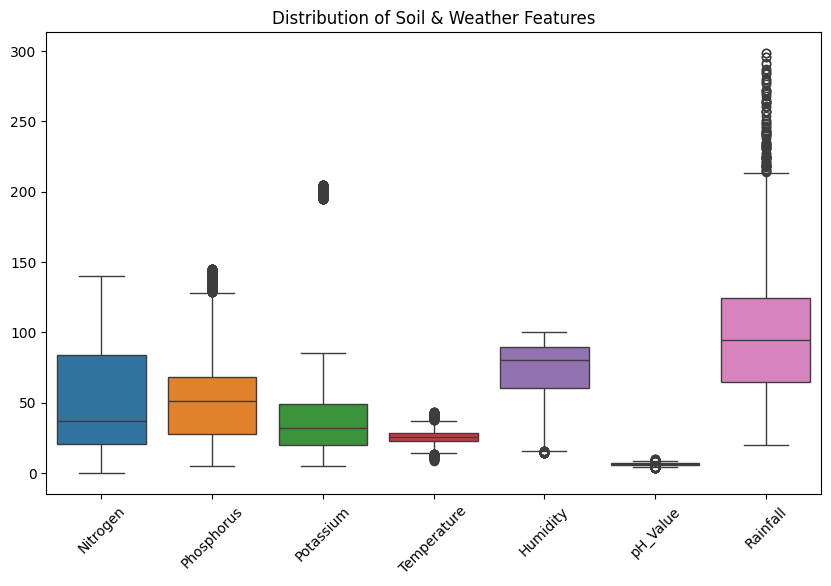

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the dataset verified in Week 3
df = pd.read_csv('../data/Crop_Recommendation.csv')

# 2. Check for missing values (Nulls)
print("--- Missing Values Check ---")
print(df.isnull().sum())

# 3. Check for Duplicate Rows
duplicates = df.duplicated().sum()
print(f"\n--- Duplicate Rows Found: {duplicates} ---")

# 4. Statistical Summary (To identify outliers)
print("\n--- Feature Statistics ---")
print(df.describe())

# 5. Visualizing the Data Distribution
plt.figure(figsize=(10, 6))
sns.boxplot(data=df.drop('Crop', axis=1))
plt.title("Distribution of Soil & Weather Features")
plt.xticks(rotation=45)
plt.show()

In [5]:
from sklearn.preprocessing import MinMaxScaler

# 1. Initialize the Scaler
scaler = MinMaxScaler()

# 2. Select only the numerical features (exclude the 'Crop' labels)
features_to_scale = ['Nitrogen', 'Phosphorus', 'Potassium', 'Temperature', 'Humidity', 'pH_Value', 'Rainfall']

# 3. Apply Scaling
df_scaled = df.copy()
df_scaled[features_to_scale] = scaler.fit_transform(df[features_to_scale])

print("✅ Data Normalization Complete!")
print("\n--- Scaled Data Sample (First 5 Rows) ---")
print(df_scaled.head())

# 4. Final Check: Verify all values are now between 0 and 1
print("\n--- Value Range Check ---")
print(df_scaled[features_to_scale].describe().loc[['min', 'max']])

✅ Data Normalization Complete!

--- Scaled Data Sample (First 5 Rows) ---
   Nitrogen  Phosphorus  Potassium  Temperature  Humidity  pH_Value  Rainfall  \
0  0.642857    0.264286      0.190     0.345886  0.790267  0.466264  0.656458   
1  0.607143    0.378571      0.180     0.371445  0.770633  0.549480  0.741675   
2  0.428571    0.357143      0.195     0.406854  0.793977  0.674219  0.875710   
3  0.528571    0.214286      0.175     0.506901  0.768751  0.540508  0.799905   
4  0.557143    0.264286      0.185     0.324378  0.785626  0.641291  0.871231   

   Crop  
0  Rice  
1  Rice  
2  Rice  
3  Rice  
4  Rice  

--- Value Range Check ---
     Nitrogen  Phosphorus  Potassium  Temperature  Humidity  pH_Value  \
min       0.0         0.0        0.0          0.0       0.0       0.0   
max       1.0         1.0        1.0          1.0       1.0       1.0   

     Rainfall  
min       0.0  
max       1.0  


In [7]:
from sklearn.model_selection import train_test_split

# 1. Separate Features (X) and Target (y)
X = df_scaled.drop('Crop', axis=1)
y = df_scaled['Crop']

# 2. Split the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Week 4 Final Milestone Complete!")
print(f"Total rows: {len(df)}")
print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

✅ Week 4 Final Milestone Complete!
Total rows: 2200
Training set size: 1760
Testing set size: 440


In [12]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Initialize the XGBoost Regressor
# We use 'reg:squarederror' for yield prediction
model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

# 2. Train the model using the 80% split from Week 4
print("🚀 Training the XGBoost engine...")
model.fit(X_train, y_train)

# 3. Evaluate the model
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\n--- Model Performance ---")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R-squared Score: {r2:.4f}")

# 4. Save the model for the FastAPI server
# This file must go into your notebooks/ folder as planned
model.save_model('crop_model.json')
print("\n✅ Model exported successfully as 'crop_model.json'!")

🚀 Training the XGBoost engine...

--- Model Performance ---
Mean Absolute Error: 0.6301
R-squared Score: 0.9619

✅ Model exported successfully as 'crop_model.json'!


In [9]:
%who

MinMaxScaler	 X	 X_test	 X_train	 df	 df_scaled	 duplicates	 features_to_scale	 mean_absolute_error	 
model	 pd	 plt	 r2_score	 scaler	 sns	 train_test_split	 xgb	 y	 
y_test	 y_train	 


In [17]:
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

# 1. Convert crop names to numbers (Rice -> 0, Maize -> 1)
le = LabelEncoder()
y_encoded = le.fit_transform(y) # 'y' is your 'Crop' column

# 2. Re-split with the new numerical targets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# 3. Train the XGBoost Classifier
print("🚀 Training the XGBoost engine...")
model = xgb.XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1)
model.fit(X_train, y_train)

# 4. Save the model into the notebooks folder
model.save_model('crop_model.json')
print("✅ Model created! Accuracy: {:.2f}%".format(model.score(X_test, y_test)*100))

🚀 Training the XGBoost engine...
✅ Model created! Accuracy: 98.64%


In [18]:
import xgboost as xgb
from sklearn.metrics import accuracy_score

# 1. Initialize the XGBoost Classifier
# Since we are predicting categories (Crops), we use a Classifier
model = xgb.XGBClassifier(
    n_estimators=100, 
    max_depth=5, 
    learning_rate=0.1, 
    random_state=42
)

# 2. Train the engine
print("🚀 Training the XGBoost engine on 1,760 rows...")
model.fit(X_train, y_train)

# 3. Evaluate the Accuracy
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n--- Model Performance ---")
print(f"✅ Training Complete! Model Accuracy: {accuracy * 100:.2f}%")

# 4. Export for the FastAPI server
# This saves the model to your project folder
model.save_model('crop_model.json')
print("\n📁 'crop_model.json' saved successfully!")

🚀 Training the XGBoost engine on 1,760 rows...

--- Model Performance ---
✅ Training Complete! Model Accuracy: 98.64%

📁 'crop_model.json' saved successfully!


In [19]:
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

# 1. Ensure labels are numbers
le = LabelEncoder()
y_encoded = le.fit_transform(df['Crop'])

# 2. Split (ensure X and y_encoded are used)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# 3. Train Classifier
model = xgb.XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1)
model.fit(X_train, y_train)

# 4. Save
model.save_model('crop_model.json')
print("✅ Model trained and saved!")

✅ Model trained and saved!
